#Engine v1 — PyTuroChamp

**AI idea:** Hand-crafted evaluation · **Era:** 1948 · **Week 3** · **Source:** [github.com/stevexyz/PyTuroChamp](https://github.com/stevexyz/PyTuroChamp) ·



## 0 · Setup — the same cell in every engine notebook

Installs python-chess if needed, finds Stockfish, and defines the small toolkit every notebook uses: `stockfish()`, `show()`, `play_game()`, `play_match()`, `greedy_bot()`, `save_results()`, `save_pgn()`. If the last line says Stockfish was **not found**, paste its path into `STOCKFISH_PATH` and re-run.

In [11]:
# ---------------------------------------------------------------- shared setup (same in every engine notebook)
#  THE TOOLKIT -- what this cell leaves behind. The same nine functions and four names are
#  in every engine notebook of the ladder, so what you learn here works in v2 through v8.
#  (In a cell, run  help(play_match)  to see any of these again without scrolling back.)
#
#  NAMES YOU CAN READ
#    IN_COLAB        True on Google Colab. When True this cell also apt-installs Stockfish.
#    STOCKFISH_PATH  Empty by default -- paste your own path here if the finder below fails.
#    STOCKFISH       Full path to the Stockfish binary, or None. Printed on the last line.
#    VALUES          Piece values in centipawns: pawn 100, knight 300, bishop 300,
#                    rook 500, queen 900, king 0 (the king is never captured, so it scores 0).
#
#  OPEN AN ENGINE, SEE A BOARD
#    stockfish(elo=None, threads=1)
#                    Start a Stockfish process and return it. Pass elo=1350 to weaken it to
#                    a club player. ALWAYS call .quit() on what it returns, or the process
#                    stays alive after the cell ends.
#    show(board, size=320)
#                    Draw the board in the notebook with the last move highlighted.
#                    Displays; returns nothing.
#
#  PLAY GAMES BETWEEN TWO BOTS
#    A "bot" here is any function that takes a board and returns a legal move --
#    greedy_bot, random_bot, and the turing_bot you write in Section 5 all qualify.
#    play_game(white_fn, black_fn, max_plies=160, start=None)
#                    Play one game; returns the finished board. start takes a FEN if you
#                    want to begin somewhere other than move 1.
#    play_match(fn_a, fn_b, games=10, max_plies=160, seed=1)
#                    Play a match with colours alternating; returns (points_for_a, decisive)
#                    where a win is 1 point, a draw 0.5, and decisive counts games that
#                    actually finished in a result. This is how you measure a change.
#
#  BOTS AND SCORING -- your opponents and your yardstick
#    random_bot(board)
#                    Plays a legal move at random. The floor: anything you write should beat it.
#    material(board, color)
#                    Centipawn material balance from color's point of view (+ is good for color).
#    greedy_bot(board)
#                    The Setup-Week baseline, three rules: play mate if you see it, else take
#                    the most material, else choose at random among equals. Scores about
#                    26-28 out of 30 against random_bot (it moves with the seed) --
#                    beat THIS and you have built something.
#
#  SAVE YOUR EVIDENCE -- both write into the portfolio layout when it exists, else here
#    save_pgn(board, name, white="?", black="?")
#                    Write a finished game to games/<name>; returns the path it used.
#    save_results(rows, header, engine_folder)
#                    Write engines/<engine_folder>/results.csv; returns the path it used.
#                    rows is a list of lists, header a list of column names.
# ----------------------------------------------------------------------------------------
%pip install chess -q
import asyncio, sys
if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
import sys, os, shutil, csv, time, random, platform
import chess, chess.engine, chess.pgn, chess.svg
from IPython.display import display, SVG, clear_output

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "-q", "stockfish"], capture_output=True)

STOCKFISH_PATH = r"C:\Users\hwang\Downloads\stockfish\stockfish-windows-x86-64-universal.exe"
STOCKFISH = next((p for p in [STOCKFISH_PATH, os.environ.get("STOCKFISH_PATH"), shutil.which("stockfish"),
                              "/usr/games/stockfish", "/usr/local/bin/stockfish", "/opt/homebrew/bin/stockfish",
                              "./stockfish", "./stockfish.exe"] if p and os.path.isfile(p)), None)

def stockfish(elo=None, threads=1):
    """Open a Stockfish process (optionally rating-limited). Remember to .quit() it."""
    if not STOCKFISH:
        raise FileNotFoundError("Stockfish not found -- set STOCKFISH_PATH (see Setup Week Kit, Step 5.1)")
    eng = chess.engine.SimpleEngine.popen_uci(STOCKFISH)
    if elo is not None:
        opt = eng.options["UCI_Elo"]
        eng.configure({"UCI_LimitStrength": True, "UCI_Elo": max(opt.min, min(opt.max, elo))})
    return eng

def show(board, size=320):
    """Draw `board` in the notebook, highlighting the last move. Displays; returns nothing."""
    display(SVG(chess.svg.board(board, size=size, lastmove=board.peek() if board.move_stack else None)))

def play_game(white_fn, black_fn, max_plies=160, start=None):
    """Two Python functions (board -> move) play a game. Returns the final board."""
    b = chess.Board(start) if start else chess.Board()
    while not b.is_game_over() and len(b.move_stack) < max_plies:
        b.push((white_fn if b.turn == chess.WHITE else black_fn)(b))
    return b

def play_match(fn_a, fn_b, games=10, max_plies=160, seed=1):
    """fn_a vs fn_b with colours alternating. Returns (points for A, decisive games)."""
    pts, decisive = 0.0, 0
    for i in range(games):
        random.seed(seed + i)
        a_white = (i % 2 == 0)
        b = play_game(fn_a, fn_b, max_plies) if a_white else play_game(fn_b, fn_a, max_plies)
        res = b.result() if b.is_game_over() else "1/2-1/2"
        if res != "1/2-1/2" and b.is_game_over(): decisive += 1
        if res == "1-0":   pts += 1 if a_white else 0
        elif res == "0-1": pts += 0 if a_white else 1
        else:              pts += 0.5
    return pts, decisive

def random_bot(board):
    """A legal move chosen at random. The weakest possible opponent -- your baseline's baseline."""
    return random.choice(list(board.legal_moves))

VALUES = {chess.PAWN: 100, chess.KNIGHT: 300, chess.BISHOP: 300, chess.ROOK: 500, chess.QUEEN: 900, chess.KING: 0}
def material(board, color):
    """Material balance in centipawns from `color`'s point of view: positive means `color` is ahead."""
    return sum(VALUES[p.piece_type] * (1 if p.color == color else -1) for p in board.piece_map().values())

def greedy_bot(board):
    """Mate if you see it, else grab the most material, random tie-break."""
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m); s = 10**6 if board.is_checkmate() else material(board, me); board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)

def save_pgn(board, name, white="?", black="?"):
    """Save a finished game as PGN into games/ (portfolio layout) if that folder exists, else here."""
    game = chess.pgn.Game.from_board(board)
    game.headers["Event"] = "Gambit Lab"; game.headers["White"] = white; game.headers["Black"] = black
    game.headers["Result"] = board.result() if board.is_game_over() else "*"
    path = os.path.join("games" if os.path.isdir("games") else ".", name)
    with open(path, "w") as f: print(game, file=f, end="\n\n")
    print("saved game ->", path)
    return path

def save_results(rows, header, engine_folder):
    """Write results.csv into engines/<folder>/ if that folder exists (portfolio layout), else here."""
    folder = os.path.join("engines", engine_folder) if os.path.isdir(os.path.join("engines", engine_folder)) else "."
    path = os.path.join(folder, "results.csv")
    with open(path, "w", newline="") as f:
        w = csv.writer(f); w.writerow(header); w.writerows(rows)
    print(f"saved {len(rows)} rows -> {path}")
    return path

print("python-chess", chess.__version__, "| Stockfish:", STOCKFISH or "NOT FOUND (only the engine cells need it)")

Note: you may need to restart the kernel to use updated packages.
python-chess 1.11.2 | Stockfish: C:\Users\hwang\Downloads\stockfish\stockfish-windows-x86-64-universal.exe


## 1 · Read first (20 minutes)

An <strong>evaluation function</strong> is a recipe that turns a position into a number: plus if White is better, minus if Black is. Turing's recipe counted material as a <em>ratio</em> (your material divided by the opponent's), then added small bonuses for mobility (how many moves you have), safety of the king, castling, and giving check.

PyTuroChamp is a modern Python reconstruction of that 1948 'paper machine'. It reads and plays through the same UCI/XBoard interface Stockfish uses. This week you build a Turing-style evaluator yourself first, then run the real thing.

**The shape of it:** <code>evaluate(position)</code> → a number &nbsp;·&nbsp; try every legal move once &nbsp;·&nbsp; keep the best number

### Why this idea, and why now

Every engine needs some way to say 'this position is good for me'. The 1948 answer was: write the judgement down as arithmetic. Material dominates (a queen is worth about nine pawns), but Turing added terms a strong player feels — pieces that can move are worth more than pieces that cannot; a king that can be checked is a liability; castling is worth a little.

Look-ahead is minimal: one ply for quiet moves, a bit more for captures ('considerable moves' — the seed of what later engines call quiescence). It plays badly by modern standards, and that is the point: you will feel exactly which weaknesses the next seven engines were invented to fix.

### Reading list — in this order

1. [Turochamp — Chess Programming Wiki](https://www.chessprogramming.org/Turochamp) — The history and the actual evaluation rules Turing used; ten minutes.
2. [Claude Shannon — Chess Programming Wiki](https://www.chessprogramming.org/Claude_Shannon) — Links to the paper itself and to the ideas it seeded.
3. [PyTuroChamp README](https://github.com/stevexyz/PyTuroChamp) — How the reconstruction is organised: pyturochamp.py (Turing's heuristics), bare.py, newt.py, ptc_xboard.py.

## 2 · Run the engine

Open the repository in a browser: [https://github.com/stevexyz/PyTuroChamp](https://github.com/stevexyz/PyTuroChamp).



Get it from GitHub
```bash
git clone https://github.com/stevexyz/PyTuroChamp.git
cd PyTuroChamp
pip install chess
```

In [12]:
# Optional: run the clone from here (handy on Colab, where there is no terminal). Set CLONE = True and run.
CLONE = True
if CLONE:
    import subprocess
    for cmd in [
    "git clone https://github.com/stevexyz/PyTuroChamp.git",
    ]:
        print("$", cmd); r = subprocess.run(cmd, shell=True, capture_output=True, text=True); print((r.stdout + r.stderr)[-600:])
else:
    print("CLONE is False -- run the commands in a terminal, or set CLONE = True here.")

$ git clone https://github.com/stevexyz/PyTuroChamp.git
fatal: destination path 'PyTuroChamp' already exists and is not an empty directory.





**Terminal — play it through the harness**

```bash
python scripts/first_engine_game.py --engine "python PyTuroChamp/ptc_xboard.py"
```

**Python — or open it directly**

```python
import chess.engine
engine = chess.engine.SimpleEngine.popen_uci(["python", "PyTuroChamp/ptc_xboard.py"])
```

Task: Open PyTuroChamp, plays a full game against an opponent you choose, prints every move as it is played, then shows the final board and writes the game to games/ as a PGN.

Write a cell for each opponent:

1. Against you
2. Against Stockfish

## 3 · Make Changes and Measure

Write an evaluation function turing_eval (material ratio, mobility, a check penalty, castling rights) and engine function turing_bot (try every legal move once, keep the best, random tie-break) by hand. Every cell runs without the real engine installed.

Turing's recipe, as arithmetic. Material is a <em>ratio</em> (his choice — it makes trades matter more when you are ahead), then three small bonuses: mobility, king safety, and castling rights. Everything is measured from the point of view of the side that just moved, so the bot can compare its options.

In [13]:
def turing_eval(board, me):
    """A Turing-style evaluation from `me`'s point of view. Bigger is better for `me`."""
    mine  = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color == me and p.piece_type != chess.KING)
    theirs = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color != me and p.piece_type != chess.KING)
    score = 100 * (mine + 100) / (theirs + 100)          # Turing's material RATIO (+100 keeps it finite)
    # mobility: how many moves would I have here?
    saved = board.turn
    board.turn = me;      my_moves = board.legal_moves.count()
    board.turn = not me;  their_moves = board.legal_moves.count()
    board.turn = saved
    score += 0.5 * (my_moves - their_moves)
    # king safety: penalty if my king is in check right now
    if board.turn == me and board.is_check():
        score -= 20
    # castling rights kept (a proxy for 'can still castle')
    score += 5 if board.has_castling_rights(me) else 0
    return score

In [14]:
# Evaluation Version 2
def turing_eval_v2(board, me):
    """Different rules for the greedy_bot"""
    mine  = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color == me and p.piece_type != chess.KING)
    theirs = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color != me and p.piece_type != chess.KING)
    score = 100 * (mine + 100) / (theirs + 100)          # Turing's material RATIO (+100 keeps it finite instead of 0)
    # mobility: how many moves would I have here?
    saved = board.turn
    board.turn = me;      my_moves = board.legal_moves.count()
    board.turn = not me;  their_moves = board.legal_moves.count()
    board.turn = saved
    score += 1.0 * (my_moves - their_moves) # Legal moves
    # king safety: penalty if my king is in check right now
    # check threat reduced to -10 point
    if board.turn == me and board.is_check():
        score -= 10
    # castling rights kept (a proxy for 'can still castle') set it half in this version to see if casteling value mattters
    # made castle 0 point v2
    score += 1 if board.has_castling_rights(me) else 0
    return score

In [15]:
def turing_bot(board):
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m)
        s = 10**6 if board.is_checkmate() else turing_eval(board, me)
        board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)

b = chess.Board()
print("Turing-bot's first move:", b.san(turing_bot(b)))
pts, dec = play_match(turing_bot, greedy_bot, games=10, max_plies=120)
print(f"Turing-bot vs Greedy: {pts}/10 points, {dec} decisive games")

Turing-bot's first move: e4
Turing-bot vs Greedy: 4.5/10 points, 3 decisive games


In [16]:

def turing_bot_v2(board):
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m)
        s = 10**6 if board.is_checkmate() else turing_eval_v2(board, me)
        board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)
# Checking new version with older one(Played against each other)
b = chess.Board()
print("Turing-bot's first move:", b.san(turing_bot_v2(b)))
pts, dec = play_match(turing_bot_v2, turing_bot, games=10, max_plies=120)
print(f"Turing-botv2 vs Original_Turing_bot: {pts}/10 points, {dec} decisive games")

Turing-bot's first move: e3
Turing-botv2 vs Original_Turing_bot: 5.5/10 points, 1 decisive games


In [17]:

def turing_bot_v2(board):
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m)
        s = 10**6 if board.is_checkmate() else turing_eval_v2(board, me)
        board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)
# Checking new version with greedy_bot(Played against each other)
b = chess.Board()
print("Turing-bot's first move:", b.san(turing_bot_v2(b)))
pts, dec = play_match(turing_bot_v2, greedy_bot, games=10, max_plies=120)
print(f"Turing-bot_v2 vs Greedy: {pts}/10 points, {dec} decisive games")

Turing-bot's first move: e3
Turing-bot_v2 vs Greedy: 5.0/10 points, 2 decisive games


Make at least one change to the evaluation function, while keeping everything else identical. For example:

1. Changing the the mobility weight 0.5 → 1.0

2. Material difference instead of ratio

3. The check penalty 20 → 50; the castling bonus 5 → 0.

Test run 20 games to see whether the engine gets stronger or weaker against the original and save the results in results.csv.

Write in RECIPE.md: what you changed and why that one; the results pasted; one sentence interpreting them that claims no more than twenty games can support.


In [18]:
def turing_eval_mobile(board, me):
    mine  = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color == me and p.piece_type != chess.KING)
    theirs = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color != me and p.piece_type != chess.KING)
    score = 100 * (mine + 100) / (theirs + 100)
    saved = board.turn
    board.turn = me;      my_moves = board.legal_moves.count()
    board.turn = not me;  their_moves = board.legal_moves.count()
    board.turn = saved
    score += 1.0 * (my_moves - their_moves)               # <-- THE ONE CHANGE (was 0.5)
    if board.turn == me and board.is_check(): score -= 20
    score += 5 if board.has_castling_rights(me) else 0
    return score

def turing_bot_mobile(board):
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m); s = 10**6 if board.is_checkmate() else turing_eval_mobile(board, me); board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)

pts, dec = play_match(turing_bot_mobile, turing_bot, games=20, max_plies=120)
print(f"mobility x2 vs original: {pts}/20 ({dec} decisive)")
save_results([["mobility_weight_1.0_vs_0.5", 20, pts, dec]],
             ["experiment", "games", "points_for_change", "decisive"], "v1-pyturochamp")

mobility x2 vs original: 10.0/20 (4 decisive)
saved 1 rows -> .\results.csv


'.\\results.csv'

In [19]:
def turing_eval_mobile_v2(board, me):
    mine  = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color == me and p.piece_type != chess.KING)
    theirs = sum(VALUES[p.piece_type] for p in board.piece_map().values() if p.color != me and p.piece_type != chess.KING)
    score = 100 * (mine + 100) / (theirs + 100)
    saved = board.turn
    board.turn = me;      my_moves = board.legal_moves.count()
    board.turn = not me;  their_moves = board.legal_moves.count()
    board.turn = saved
    score += 1.0 * (my_moves - their_moves)               # <-- THE ONE CHANGE (was 0.5)
    if board.turn == me and board.is_check(): score -= 20
    score += 5 if board.has_castling_rights(me) else 0
    return score

def turing_bot_mobile(board):
    me, best, moves = board.turn, None, []
    for m in board.legal_moves:
        board.push(m); s = 10**6 if board.is_checkmate() else turing_eval_mobile_v2(board, me); board.pop()
        if best is None or s > best: best, moves = s, [m]
        elif s == best: moves.append(m)
    return random.choice(moves)

pts, dec = play_match(turing_bot_mobile, turing_bot_v2, games=20, max_plies=120)
print(f"mobility x2 vs original: {pts}/20 ({dec} decisive)")
save_results([["mobility_weight_1.0_vs_0.5", 20, pts, dec]],
             ["experiment", "games", "points_for_change", "decisive"], "v1-pyturochamp")

mobility x2 vs original: 9.0/20 (6 decisive)
saved 1 rows -> .\results.csv


'.\\results.csv'

In [20]:
def human_bot(board):
    """You play: shows the board, asks for a move, retries until it's legal."""
    show(board)
    while True:
        text = input("Your move (e.g. e5 or Nf6): ").strip()
        try:
            move = board.parse_san(text)            # standard notation: e5, Nf6, O-O
        except ValueError:
            try:
                move = chess.Move.from_uci(text)    # also accepts e7e5 style
            except ValueError:
                print("Can't read that, try again.")
                continue
        if move in board.legal_moves:
            print("You played:", board.san(move))
            return move
        print("Illegal move, try again.")

In [21]:
import io, contextlib
sys.path.insert(0, "PyTuroChamp")
import pyturochamp as ptc
ptc.MAXPLIES = 2; ptc.QPLIES = ptc.MAXPLIES + 4   # depth 2: seconds per move instead of up to ~90 s
os.makedirs("games", exist_ok=True)

def tag(board): return f"{board.fullmove_number}{'.' if board.turn else '...'}"

def ptc_bot(board):
    with contextlib.redirect_stdout(io.StringIO()):
        _, pv = ptc.getmove(board.copy(), silent=True)
    move = chess.Move.from_uci(pv[0])
    print(tag(board), "PyTuroChamp:", board.san(move))
    return move

def human_bot(board):
    show(board)
    while True:
        text = input("Your move (e5, Nf6, O-O or e7e5): ").strip()
        try:
            move = board.parse_san(text)
        except ValueError:
            try: move = chess.Move.from_uci(text.lower())
            except ValueError: print("Can't read that."); continue
        if move in board.legal_moves:
            print(tag(board), "You:", board.san(move)); return move
        print("Illegal move.")

1. PyTuroChamp: e4


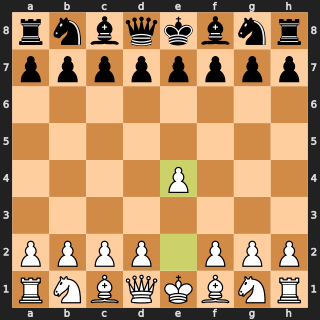

1... You: d5
2. PyTuroChamp: d4


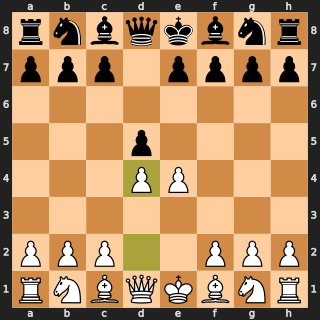

2... You: dxe4
3. PyTuroChamp: Nc3


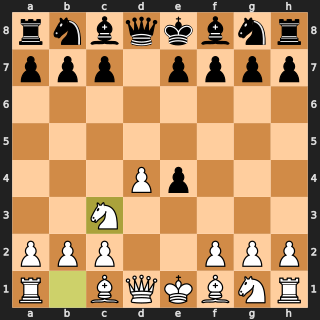

Can't read that.
3... You: Nf6
4. PyTuroChamp: Be3


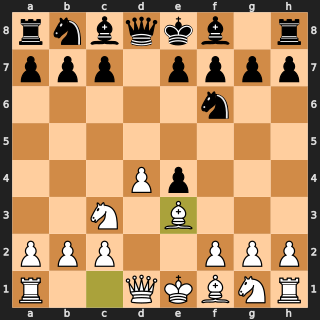

4... You: Nc6
5. PyTuroChamp: h4


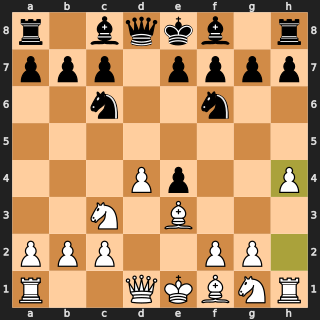

5... You: Bg4
6. PyTuroChamp: Be2


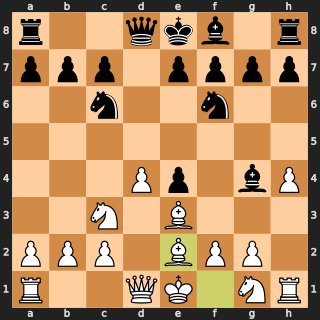

6... You: Qd7
7. PyTuroChamp: d5


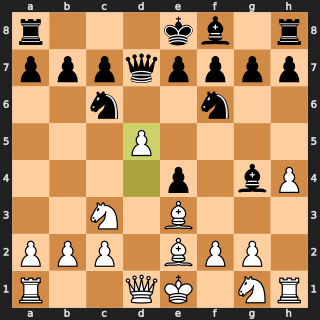

7... You: Bxe2
8. PyTuroChamp: Ngxe2


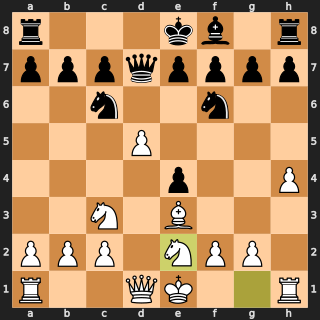

8... You: Ne5
9. PyTuroChamp: Ng3


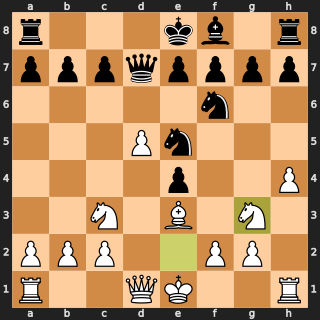

Can't read that.
Can't read that.
Can't read that.
9... You: O-O-O
10. PyTuroChamp: O-O


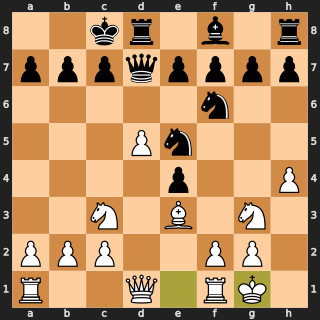

10... You: Nxd5
11. PyTuroChamp: Qxd5


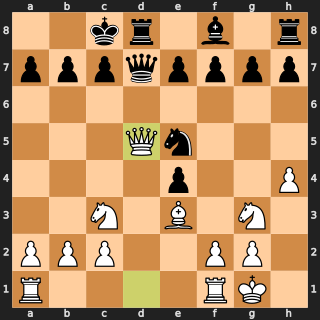

Can't read that.
11... You: Qxd5
12. PyTuroChamp: Nxd5


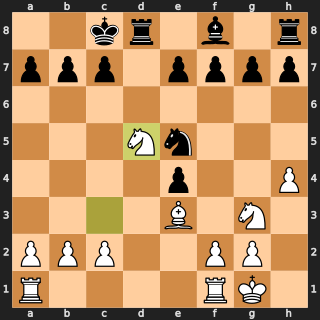

12... You: Rxd5
13. PyTuroChamp: a4


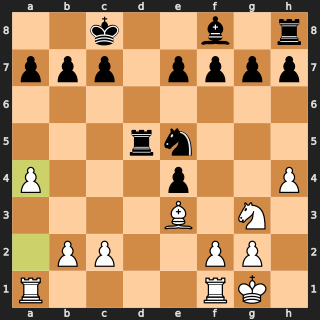

13... You: e6
14. PyTuroChamp: Rfd1


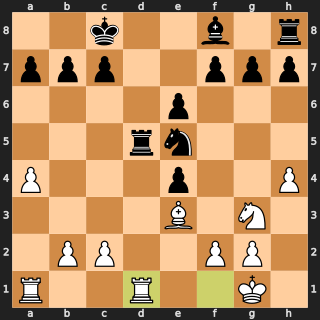

14... You: Rxd1+
15. PyTuroChamp: Rxd1


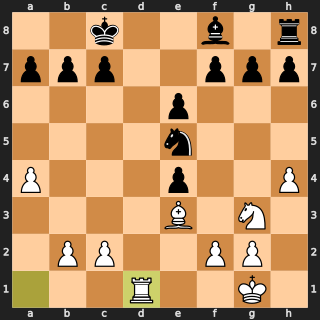

15... You: Be7
16. PyTuroChamp: h5


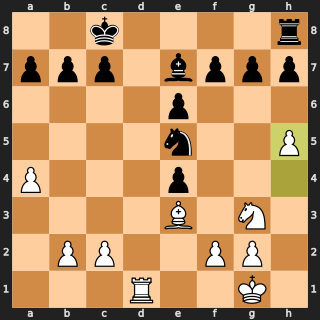

16... You: Rd8
17. PyTuroChamp: Bd4


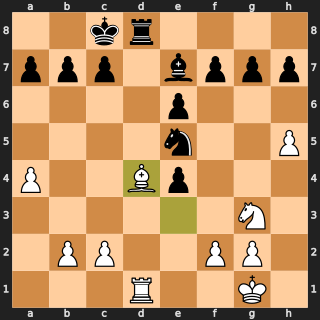

17... You: Nc6
18. PyTuroChamp: c3


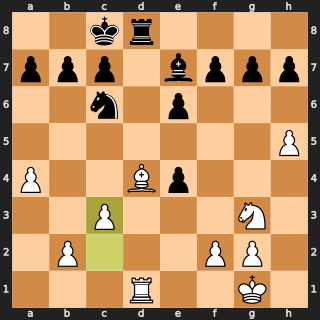

18... You: e5
19. PyTuroChamp: Nf5


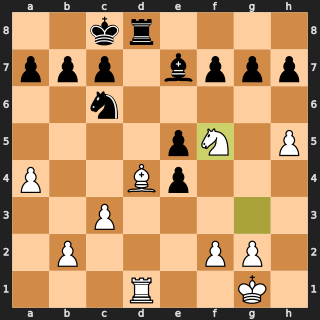

19... You: exd4
20. PyTuroChamp: h6


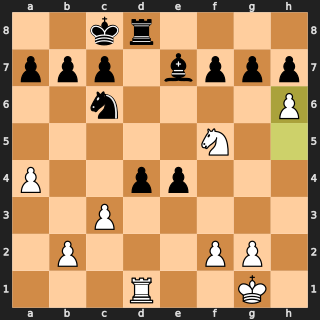

20... You: g6
21. PyTuroChamp: Nxd4


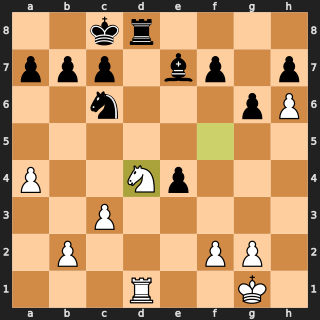

21... You: Nxd4
22. PyTuroChamp: cxd4


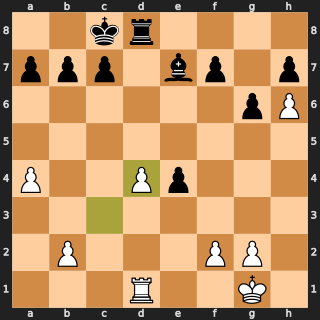

22... You: Bg5
23. PyTuroChamp: f4


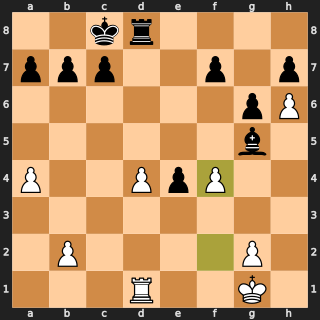

23... You: Bxf4
24. PyTuroChamp: a5


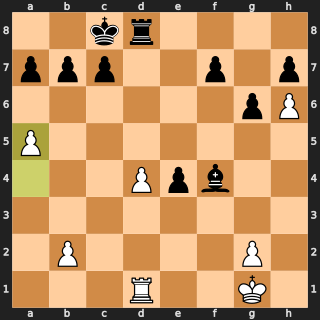

24... You: Be3+
25. PyTuroChamp: Kh1


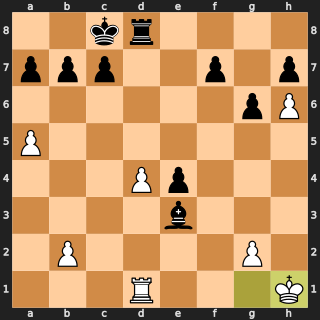

25... You: Rxd4
26. PyTuroChamp: Rf1


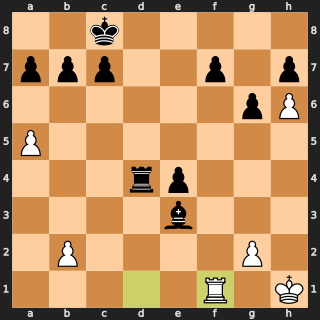

26... You: Bxh6
27. PyTuroChamp: Rxf7


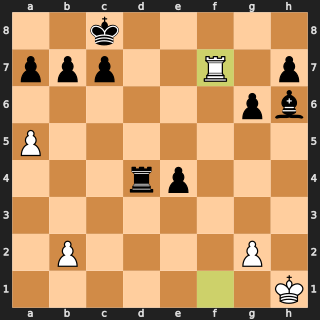

27... You: e3
28. PyTuroChamp: Kg1


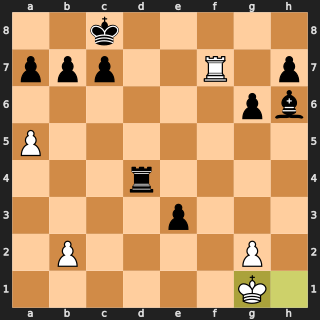

28... You: e2
29. PyTuroChamp: Kf2


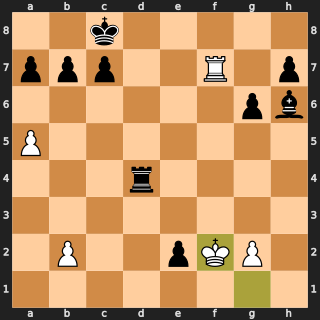

29... You: Re4
30. PyTuroChamp: Rxc7+


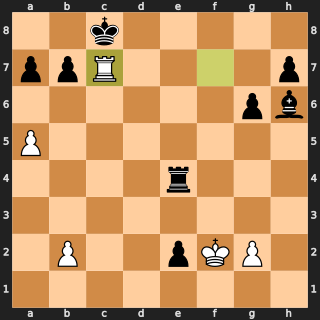

30... You: Kxc7
31. PyTuroChamp: Kf3


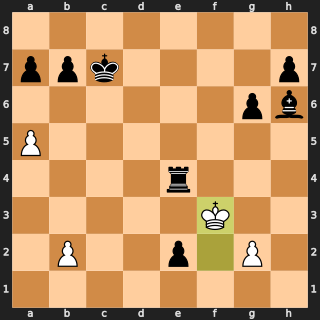

31... You: Re3+
32. PyTuroChamp: Kg4


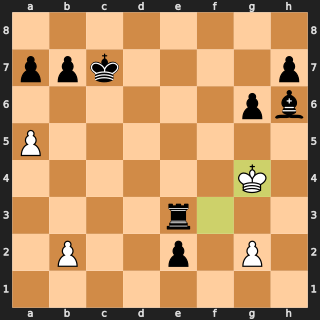

Can't read that.
32... You: e1=Q
33. PyTuroChamp: a6


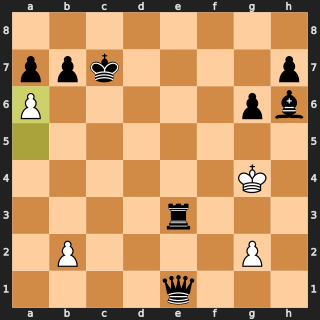

33... You: Qg3#


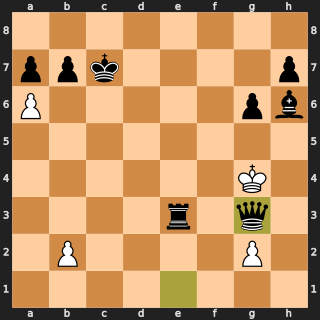

Result: 0-1
saved game -> games\v1-vs-me.pgn


'games\\v1-vs-me.pgn'

In [11]:
board = play_game(ptc_bot, human_bot, max_plies=200)
show(board); print("Result:", board.result() if board.is_game_over() else "unfinished")
save_pgn(board, "v1-vs-me.pgn", white="PyTuroChamp", black="Me")

1. PyTuroChamp: e4
1... Stockfish: e5
2. PyTuroChamp: d4
2... Stockfish: exd4
3. PyTuroChamp: h4
3... Stockfish: Bc5
4. PyTuroChamp: a4
4... Stockfish: Qe7
5. PyTuroChamp: Nc3
5... Stockfish: Nc6
6. PyTuroChamp: Bg5
6... Stockfish: Nf6
7. PyTuroChamp: Bc4
7... Stockfish: dxc3
8. PyTuroChamp: bxc3
8... Stockfish: Bb6
9. PyTuroChamp: Bd5
9... Stockfish: a5
10. PyTuroChamp: Ne2
10... Stockfish: Nd8
11. PyTuroChamp: O-O
11... Stockfish: c6
12. PyTuroChamp: Rb1
12... Stockfish: Ra6
13. PyTuroChamp: Rxb6
13... Stockfish: Rxb6
14. PyTuroChamp: Qd4
14... Stockfish: Ra6
15. PyTuroChamp: Bc4
15... Stockfish: Ne6
16. PyTuroChamp: Qe5
16... Stockfish: d6
17. PyTuroChamp: Qf5
17... Stockfish: Ra8
18. PyTuroChamp: Bxe6
18... Stockfish: fxe6
19. PyTuroChamp: Qf3
19... Stockfish: Bd7
20. PyTuroChamp: Nd4
20... Stockfish: Qf8
21. PyTuroChamp: Rd1
21... Stockfish: e5
22. PyTuroChamp: Nf5
22... Stockfish: Bxf5
23. PyTuroChamp: Qxf5
23... Stockfish: Ke7
24. PyTuroChamp: h5
24... Stockfish: h6
25. PyTuroCh

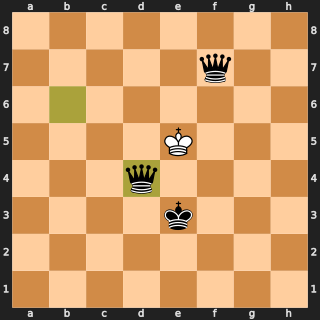

Result: 0-1
saved game -> games\v1-vs-stockfish.pgn


'games\\v1-vs-stockfish.pgn'

In [22]:
sf = stockfish(elo=1350)
def sf_bot(board):
    move = sf.play(board, chess.engine.Limit(time=0.1)).move
    print(tag(board), "Stockfish:", board.san(move)); return move
try:
    board = play_game(ptc_bot, sf_bot, max_plies=200)
finally:
    sf.quit()
show(board); print("Result:", board.result() if board.is_game_over() else "unfinished")
save_pgn(board, "v1-vs-stockfish.pgn", white="PyTuroChamp", black="Stockfish 1350")